HÜCRE 1 — Hipertansif Retinopati (Task2) maskeleme + kontrol + görseller

In [ ]:
# =========================
# TASK2 (Hypertensive Retinopathy) - Vessel Soft Map Generation
# =========================

# 1) KURULUM: Subprocess yerine bunu kullanın.
# Versiyon hatalarını önlemek için kısıtlamaları kaldırdık, en uyumlu sürümler yüklenecek.
!pip install segmentation-models-pytorch timm

import os, glob, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import segmentation_models_pytorch as smp
from google.colab import drive

# ---- 0) Drive mount ----
if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")
else:
    print("✅ Drive already mounted")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Device:", device)

# ---- 1) Paths (senin verdiğin) ----
SEG_ROOT = "/content/drive/My Drive/Colab Notebooks/drive_retinal/TEZ/runs_segmentation"
CKPT_ROOT = os.path.join(SEG_ROOT, "unetpp_resnet34_crop512_seed42")

# GÖRÜNTÜ KLASÖRÜNÜ BURADAN KONTROL ET (Task 2 klasörün hangisiyse onu yaz)
IMG_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/images"
LABEL_CSV = "/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/hr_etiket.csv"

OUT_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/24aralikMaske"
os.makedirs(OUT_DIR, exist_ok=True)

ENCODER = "resnet34"
SIZE = 512
SAVE_PNG_PREVIEW = True
SHOW_SAMPLES = 3
SEED = 42
random.seed(SEED)

# ---- 2) Quick checks ----
if not os.path.exists(IMG_DIR):
    raise FileNotFoundError(f"❌ IMG_DIR not found: {IMG_DIR}")
if not os.path.exists(LABEL_CSV):
    print(f"⚠️ LABEL CSV not found (you can still generate masks): {LABEL_CSV}")
else:
    df = pd.read_csv(LABEL_CSV)
    print("✅ Label CSV loaded:", LABEL_CSV)
    print("   shape:", df.shape)

# Count images
exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
img_paths = sorted([os.path.join(IMG_DIR, f) for f in os.listdir(IMG_DIR) if f.lower().endswith(exts)])
print(f"📷 Task2 images found: {len(img_paths)}")
if len(img_paths) > 0:
    print("   example files:", [os.path.basename(p) for p in img_paths[:5]])
else:
    print("⚠️ HİÇ RESİM BULUNAMADI! Lütfen IMG_DIR yolunu kontrol edin.")

# ---- 3) Model + Ensemble loader ----
def build_unetpp():
    return smp.UnetPlusPlus(
        encoder_name=ENCODER,
        encoder_weights=None,
        in_channels=1,
        classes=1,
        activation=None
    )

def load_ensemble():
    models = []
    # 5 Fold'u yükle
    for k in range(1, 6):
        ckpt_path = os.path.join(CKPT_ROOT, f"fold_{k}", "best.pth")

        if not os.path.exists(ckpt_path):
            print(f"⚠️ UYARI: Checkpoint bulunamadı, atlanıyor: {ckpt_path}")
            continue

        m = build_unetpp().to(device)
        try:
            ckpt = torch.load(ckpt_path, map_location=device)
            # Eğer checkpoint içinde 'model' anahtarı varsa onu al, yoksa direkt state_dict'tir
            state_dict = ckpt["model"] if "model" in ckpt else ckpt
            m.load_state_dict(state_dict)
            m.eval()
            models.append(m)
        except Exception as e:
            print(f"❌ Checkpoint yüklenirken hata: {ckpt_path}\n{e}")

    if len(models) == 0:
        raise RuntimeError("❌ Hiçbir model yüklenemedi! Lütfen CKPT_ROOT yolunu kontrol edin.")

    print(f"✅ Loaded {len(models)} checkpoints (ensemble).")
    return models

def read_green_clahe(img_path):
    bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if bgr is None:
        return None, None
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    g = rgb[..., 1]
    g = cv2.resize(g, (SIZE, SIZE), interpolation=cv2.INTER_LINEAR)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g = clahe.apply(g)
    g = g.astype(np.float32) / 255.0
    return rgb, g  # rgb(512,512,3), g(512,512)

@torch.no_grad()
def predict_ensemble(models, g_img):
    x = torch.from_numpy(g_img).unsqueeze(0).unsqueeze(0).float().to(device)  # (1,1,H,W)
    probs = []
    for m in models:
        logits = m(x)
        prob = torch.sigmoid(logits)[0,0].detach().cpu().numpy()
        probs.append(prob)
    return np.mean(probs, axis=0).astype(np.float32)

def save_soft(out_dir, base, soft):
    npy_path = os.path.join(out_dir, base + "_vessel.npy")
    png_path = os.path.join(out_dir, base + "_vessel.png")
    np.save(npy_path, soft.astype(np.float32))
    if SAVE_PNG_PREVIEW:
        # Görselleştirme için 0-255 yap
        cv2.imwrite(png_path, (soft * 255).astype(np.uint8))
    return npy_path, png_path

# ---- 4) RUN generation ----
# Modelleri yükle
models = load_ensemble()

if len(img_paths) > 0:
    print("\n🚀 Generating vessel maps for Task2...")
    for p in tqdm(img_paths):
        base = os.path.splitext(os.path.basename(p))[0]
        rgb, g = read_green_clahe(p)
        if g is None:
            print(f"⚠️ Okunamayan dosya: {p}")
            continue

        soft = predict_ensemble(models, g)
        save_soft(OUT_DIR, base, soft)

    print("✅ Done. Saved to:", OUT_DIR)

    # ---- 5) Show sample comparisons (original vs soft vs overlay) ----
    print("\n🖼️ Showing sample outputs...")
    sample_paths = random.sample(img_paths, k=min(SHOW_SAMPLES, len(img_paths)))

    for p in sample_paths:
        base = os.path.splitext(os.path.basename(p))[0]
        rgb, g = read_green_clahe(p)

        # Soft map'i diskten okuyalım (kontrol amaçlı) veya memory'den alalım
        soft_path = os.path.join(OUT_DIR, base + "_vessel.png")
        if os.path.exists(soft_path):
            soft_png = cv2.imread(soft_path, cv2.IMREAD_GRAYSCALE)
            soft = soft_png.astype(np.float32) / 255.0
        else:
            continue

        # overlay on original RGB (red mask)
        overlay = rgb.copy()
        heat = (soft * 255).astype(np.uint8)
        # Kırmızı kanala ekle
        overlay[..., 0] = np.clip(overlay[..., 0] + heat, 0, 255)

        plt.figure(figsize=(18,5))
        plt.suptitle(f"Task2 | {os.path.basename(p)}", y=1.02)

        plt.subplot(1,3,1); plt.title("Original (RGB resized 512)"); plt.imshow(rgb); plt.axis("off")
        plt.subplot(1,3,2); plt.title("Vessel soft map"); plt.imshow(soft, cmap="gray"); plt.axis("off")
        plt.subplot(1,3,3); plt.title("Overlay (R+=softmap)"); plt.imshow(overlay); plt.axis("off")
        plt.show()

    print("✅ Sample visualization complete.")
else:
    print("❌ İşlenecek görüntü bulunamadığı için işlem yapılmadı.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.5 MB/s eta 0:00:00
Mounted at /content/drive
✅ Device: cuda
✅ Label CSV loaded: /content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/hr_etiket.csv
   shape: (712, 2)
📷 Task2 images found: 712
   example files: ['00000ce7.png', '00000ce9.png', '00000de9.png', '00000dea.png', '0000111e.png']
✅ Loaded 5 checkpoints (ensemble).

🚀 Generating vessel maps for Task2...


100%|██████████| 712/712 [04:11<00:00,  2.84it/s]

✅ Done. Saved to: /content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/24aralikMaske

🖼️ Showing sample outputs...


ValueError: operands could not be broadcast together with shapes (800,800) (512,512) 

✅ Maskeler zaten üretilmişti. Şimdi 5 örnek görselleştiriliyor...


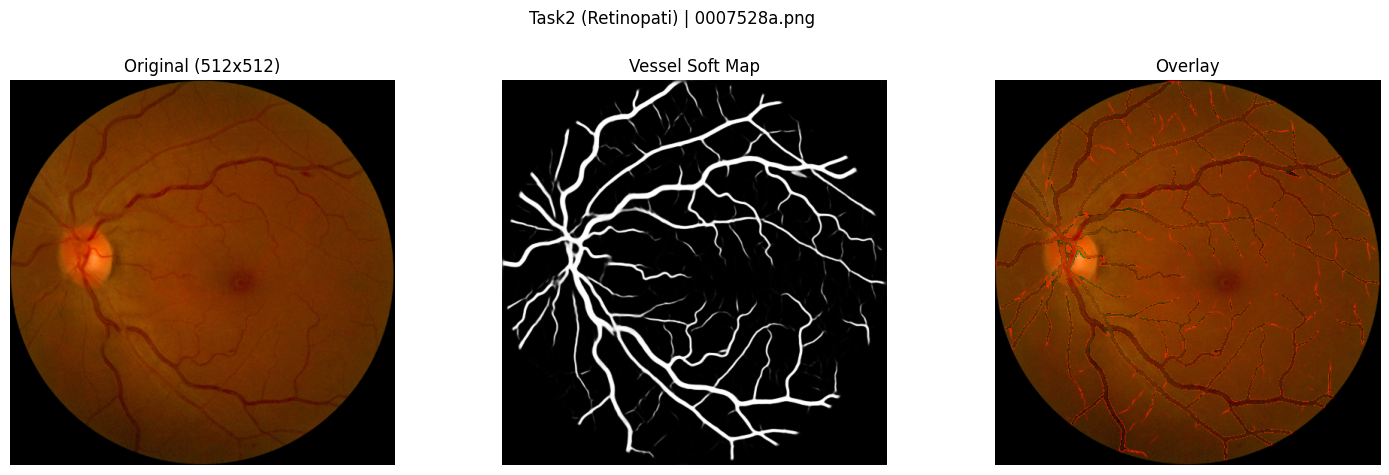

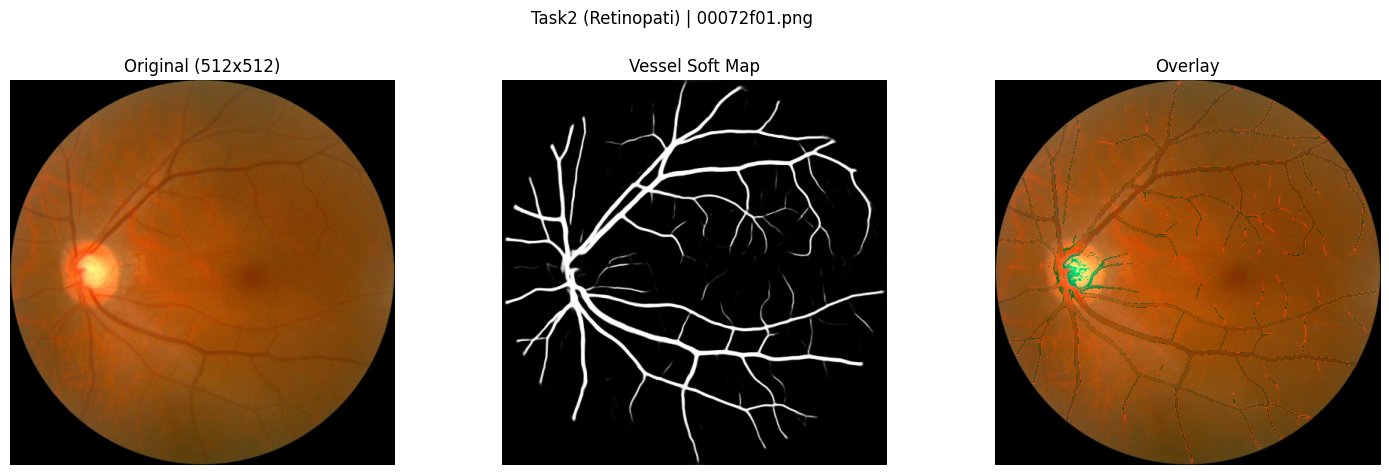

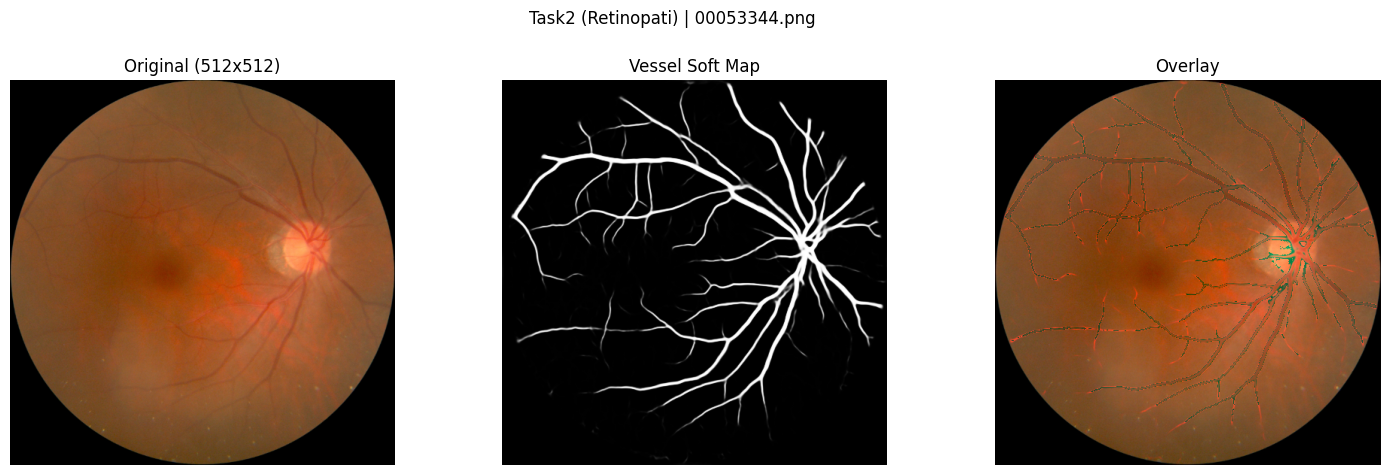

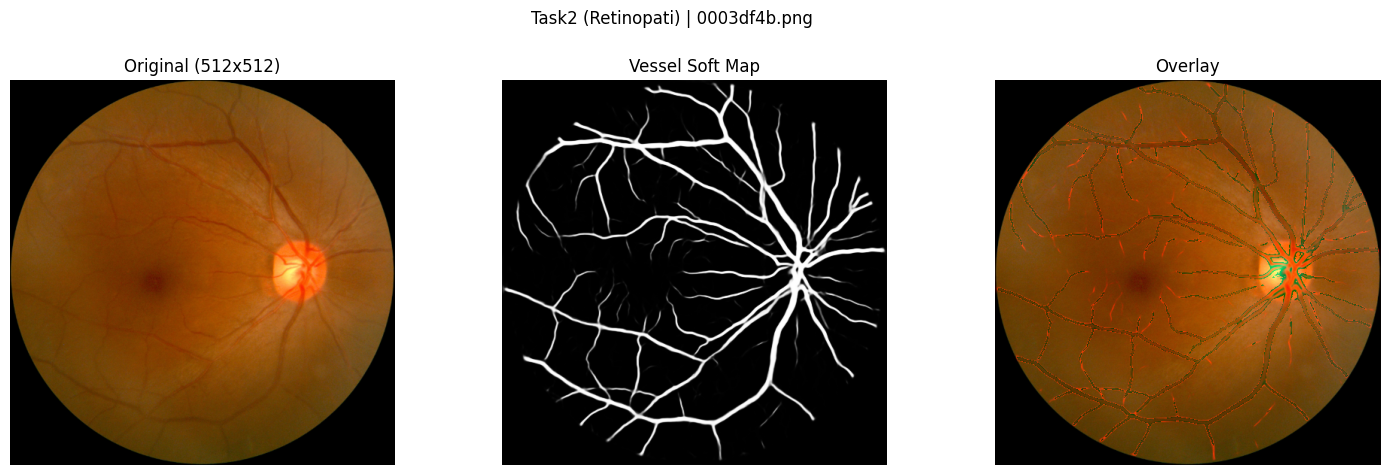

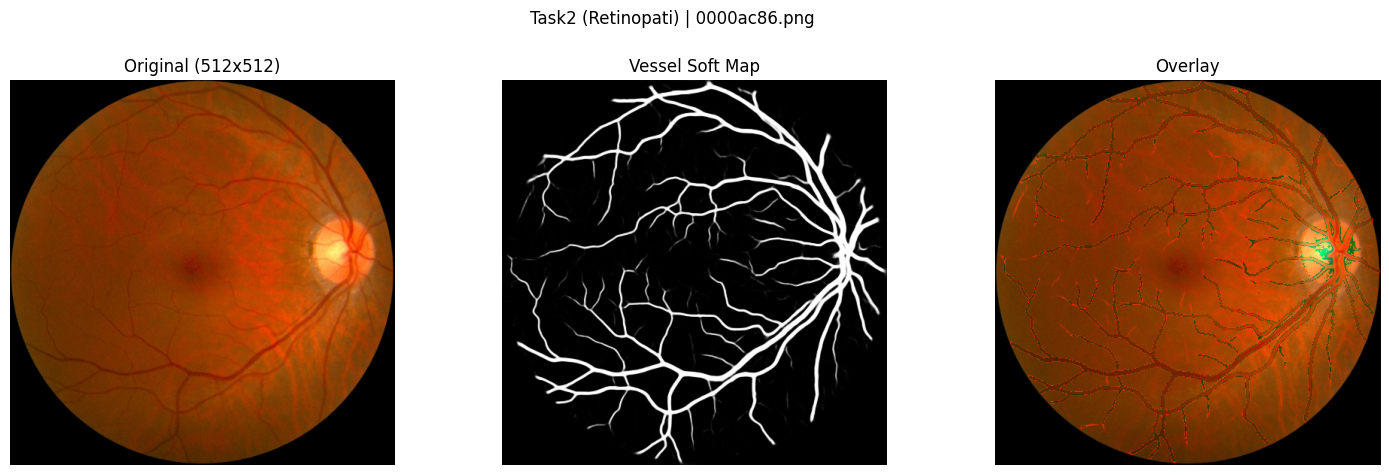

✅ Görselleştirme tamamlandı.


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np

# Ayarlar (Önceki koddan geldiği varsayılıyor)
OUT_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/24aralikMaske"
IMG_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/images"
SIZE = 512
SHOW_SAMPLES = 5

# Resim yollarını tekrar alalım
exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
img_paths = sorted([os.path.join(IMG_DIR, f) for f in os.listdir(IMG_DIR) if f.lower().endswith(exts)])

print(f"✅ Maskeler zaten üretilmişti. Şimdi {SHOW_SAMPLES} örnek görselleştiriliyor...")

# Rastgele örnekler seç
sample_paths = random.sample(img_paths, k=min(SHOW_SAMPLES, len(img_paths)))

for p in sample_paths:
    base = os.path.splitext(os.path.basename(p))[0]

    # 1. Orijinal resmi oku ve RESIZE ET (Hatayı düzelten kısım burası)
    bgr = cv2.imread(p)
    if bgr is None: continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_resized = cv2.resize(rgb, (SIZE, SIZE), interpolation=cv2.INTER_LINEAR) # 512x512 oldu

    # 2. Üretilmiş maskeyi diskten oku
    soft_path = os.path.join(OUT_DIR, base + "_vessel.png")
    if os.path.exists(soft_path):
        soft_png = cv2.imread(soft_path, cv2.IMREAD_GRAYSCALE)
        soft = soft_png.astype(np.float32) / 255.0
    else:
        print(f"Maske bulunamadı: {base}")
        continue

    # 3. Overlay (Artık boyutlar 512x512 olduğu için hata vermeyecek)
    overlay = rgb_resized.copy()
    heat = (soft * 255).astype(np.uint8)
    # Kırmızı kanala damarları ekle (Görsel efekt)
    overlay[..., 0] = np.clip(overlay[..., 0] + heat, 0, 255)

    # 4. Çizdir
    plt.figure(figsize=(18,5))
    plt.suptitle(f"Task2 (Retinopati) | {os.path.basename(p)}", y=1.02)

    plt.subplot(1,3,1); plt.title("Original (512x512)"); plt.imshow(rgb_resized); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Vessel Soft Map"); plt.imshow(soft, cmap="gray"); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
    plt.show()

print("✅ Görselleştirme tamamlandı.")

In [ ]:
import os, glob

OUT_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/24aralikMaske"
IMG_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/images"

exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
imgs = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(exts)]
pngs = glob.glob(os.path.join(OUT_DIR, "*_vessel.png"))
npys = glob.glob(os.path.join(OUT_DIR, "*_vessel.npy"))

print("Task2 image count:", len(imgs))
print("Task2 vessel PNG count:", len(pngs))
print("Task2 vessel NPY count:", len(npys))

# hızlı isim uyumu kontrolü (kaç tanesi karşılık geliyor)
img_bases = set(os.path.splitext(f)[0] for f in imgs)
png_bases = set(os.path.basename(f).replace("_vessel.png","") for f in pngs)
print("PNG matched to images:", len(img_bases & png_bases))


Task2 image count: 712
Task2 vessel PNG count: 712
Task2 vessel NPY count: 712
PNG matched to images: 712


Task2 (Hipertansif Retinopati) – Maskeleme / Vessel Soft Map Üretimi (Özet)
1) Kullanılan segmentasyon modeli

DRIVE damar segmentasyonunda eğitilmiş U-Net++ (ResNet34 encoder) modeli kullanıldı.

Modelin 5-fold eğitiminden elde edilen 5 ayrı best.pth checkpoint birlikte kullanılarak ensemble yapıldı.

Ensemble yaklaşımı: Aynı görüntü için 5 modelden elde edilen olasılık haritaları ortalaması alınarak tek bir “soft map” üretildi.

2) Girdi veri seti (Task2)

Görüntü klasörü:
/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/images

Etiket dosyası (sadece kontrol amaçlı):
/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/hr_etiket.csv

3) Ön işleme (her görüntü için)

Görüntü okundu (RGB).

Görüntü 512×512 boyutuna yeniden ölçeklendirildi.

Damarları daha belirgin yapmak için yeşil kanal (G channel) alındı.

Yeşil kanala CLAHE (kontrast artırma) uygulandı.

Model girdisi olarak tek kanal (1×512×512) hazırlandı.

4) Tahmin / maske üretimi

U-Net++ modellerinden her biri görüntü için logits üretti.

Logits üzerine sigmoid uygulanarak 0–1 arası damar olasılık haritası (soft map) elde edildi.

5 fold modelin çıktıları ortalama alınarak tek bir final soft map üretildi.

5) Çıktıların kaydedilmesi

Çıktı klasörü:
/content/drive/My Drive/Colab Notebooks/TEZ/hr_veri/24aralikMaske

Her görüntü için iki dosya üretildi:

*_vessel.npy → float32, 0–1 arası soft map (asıl kullanılacak çıktı)

*_vessel.png → 0–255 gri seviye görsel (hızlı kontrol amaçlı)

6) Doğrulama kontrolleri

Task2 görüntü sayısı kontrol edildi: 712

Üretilen maske sayıları kontrol edildi:

712 adet _vessel.png

712 adet _vessel.npy

Dosya adı eşleşmesi kontrol edildi:

PNG matched to images: 712/712

Sonuç: Task2 için maskeleme işlemi eksiksiz ve hatasız tamamlandı.

7) Görsel kontrol (ekran çıktısı)

Rastgele seçilen örneklerde şu üçlü karşılaştırma gösterildi:

Orijinal görüntü (512×512)

Vessel soft map

Overlay (orijinal görüntü üzerine damar haritası kırmızı olarak bindirildi)

Amaç: Maskelerin anatomik olarak damar bölgelerine oturduğunu görsel olarak doğrulamak.

**TASK1 Hipertansif Veri Seti Maskeleme**

✅ Drive already mounted
✅ Device: cuda
✅ Label CSV loaded: /content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/csv/etiket.csv
   shape: (712, 2)
   columns: ['Image', 'Hypertensive']
📷 Task1 images found: 712
   example files: ['00000dc7.png', '00000de9.png', '00000ee3.png', '00001121.png', '0000115b.png']
✅ Loaded 5 checkpoints (ensemble).

🚀 Generating vessel maps for Task1...


100%|██████████| 712/712 [03:40<00:00,  3.23it/s]


✅ Done. Saved to: /content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/24aralikMaske

📊 OUTPUT COUNTS
Task1 image count: 712
Task1 vessel PNG count: 712
Task1 vessel NPY count: 712
PNG matched to images: 712

🖼️ Showing sample outputs...


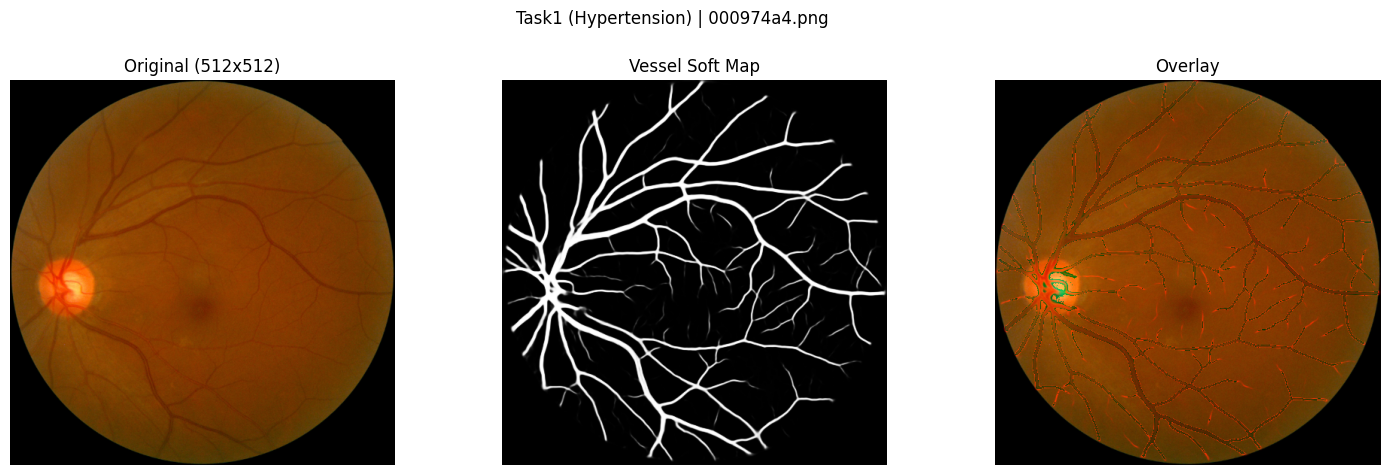

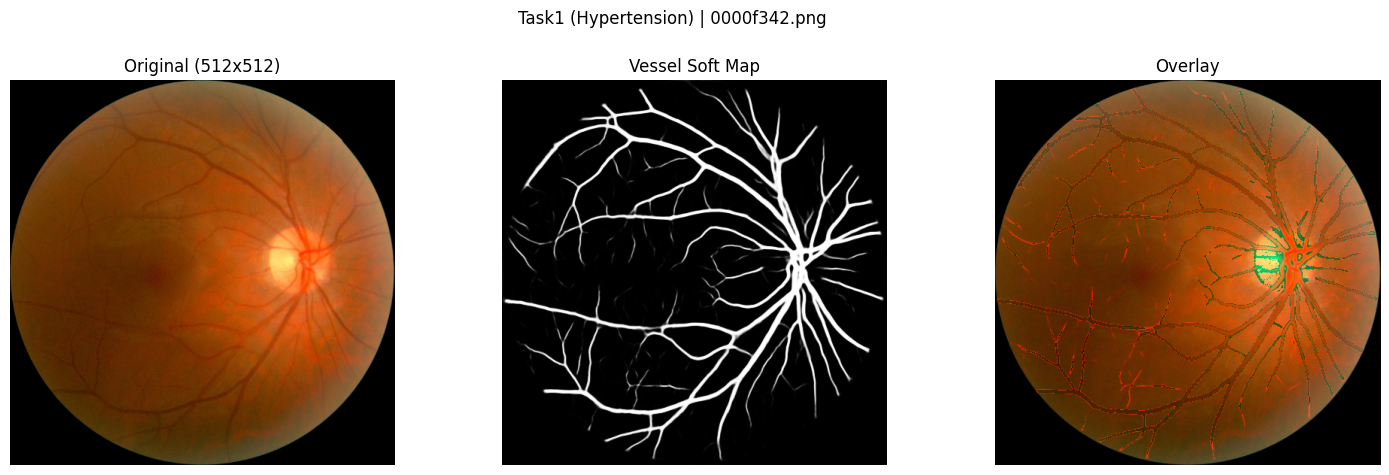

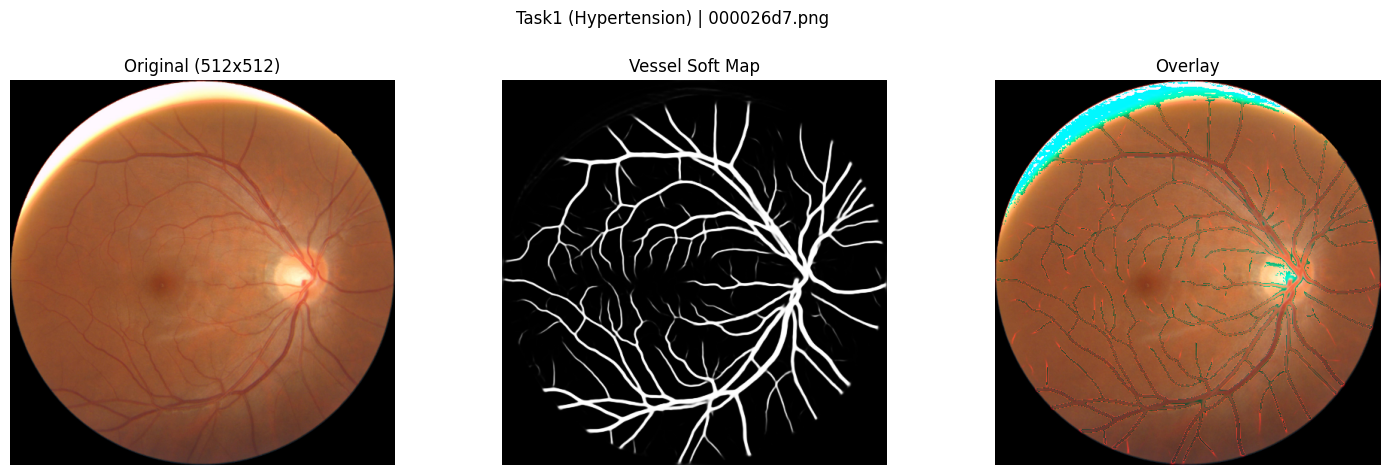

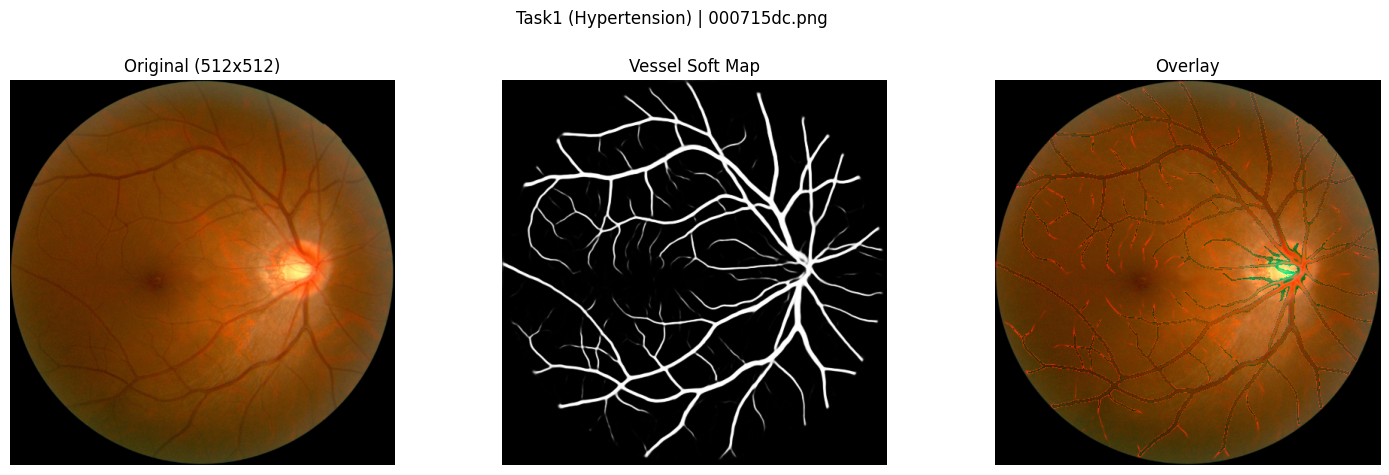

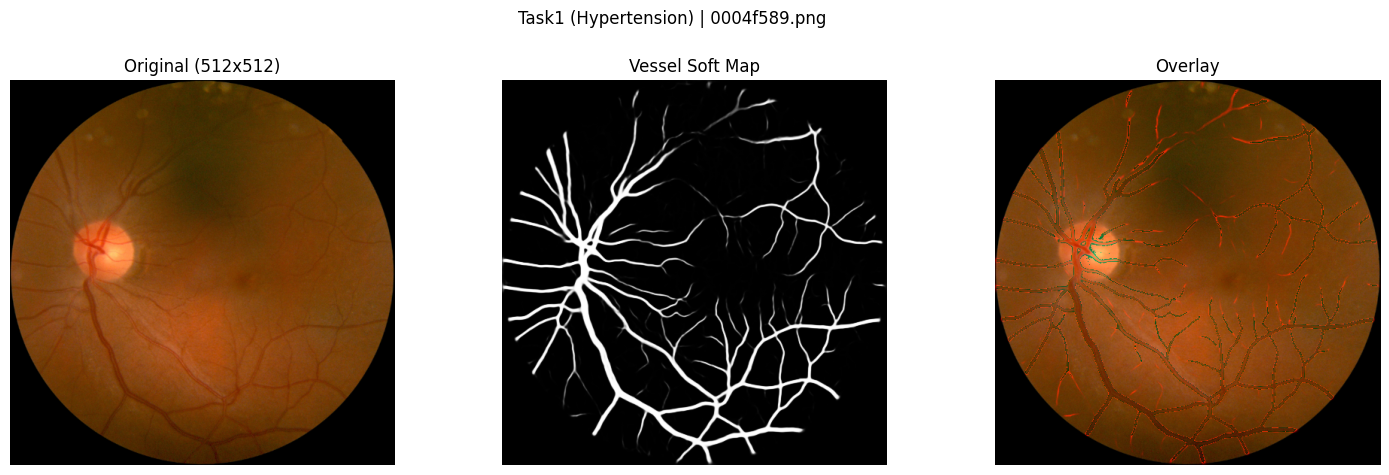

✅ Task1 visualization complete.


In [ ]:
# =========================
# TASK1 (Hypertension) - Vessel Soft Map Generation + Checks + Visualization
# UNet++ 5-fold ensemble (DRIVE-trained)
# =========================

# Eğer bir önceki hücrede SMP kurulmadıysa aç:
# !pip -q install segmentation-models-pytorch opencv-python tqdm pandas matplotlib

import os, random, glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import segmentation_models_pytorch as smp
from google.colab import drive

# ---- 0) Drive mount ----
if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")
else:
    print("✅ Drive already mounted")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Device:", device)

# ---- 1) PATHS (senin verdiğin) ----
SEG_ROOT = "/content/drive/My Drive/Colab Notebooks/drive_retinal/TEZ/runs_segmentation"
CKPT_ROOT = os.path.join(SEG_ROOT, "unetpp_resnet34_crop512_seed42")

IMG_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/images"
LABEL_CSV = "/content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/csv/etiket.csv"

OUT_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/24aralikMaske"
os.makedirs(OUT_DIR, exist_ok=True)

ENCODER = "resnet34"
SIZE = 512
SAVE_PNG_PREVIEW = True
SHOW_SAMPLES = 5
SEED = 42
random.seed(SEED)

# ---- 2) Quick checks ----
if not os.path.exists(IMG_DIR):
    raise FileNotFoundError(f"❌ IMG_DIR not found: {IMG_DIR}")

if os.path.exists(LABEL_CSV):
    df = pd.read_csv(LABEL_CSV)
    print("✅ Label CSV loaded:", LABEL_CSV)
    print("   shape:", df.shape)
    print("   columns:", list(df.columns)[:10])
else:
    print("⚠️ Label CSV not found (mask generation will still run):", LABEL_CSV)

exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
imgs = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith(exts)])
img_paths = [os.path.join(IMG_DIR, f) for f in imgs]

print(f"📷 Task1 images found: {len(img_paths)}")
print("   example files:", imgs[:5])

# ---- 3) Ensemble model loader ----
def build_unetpp():
    return smp.UnetPlusPlus(
        encoder_name=ENCODER,
        encoder_weights=None,
        in_channels=1,
        classes=1,
        activation=None
    )

def load_ensemble():
    models = []
    for k in range(1, 6):
        ckpt_path = os.path.join(CKPT_ROOT, f"fold_{k}", "best.pth")
        if not os.path.exists(ckpt_path):
            raise FileNotFoundError(f"❌ Missing checkpoint: {ckpt_path}")
        m = build_unetpp().to(device)
        ckpt = torch.load(ckpt_path, map_location=device)
        m.load_state_dict(ckpt["model"])
        m.eval()
        models.append(m)
    print(f"✅ Loaded {len(models)} checkpoints (ensemble).")
    return models

def read_green_clahe(img_path):
    bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(img_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_resized = cv2.resize(rgb, (SIZE, SIZE), interpolation=cv2.INTER_LINEAR)

    g = rgb_resized[..., 1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g = clahe.apply(g)
    g = g.astype(np.float32) / 255.0
    return rgb_resized, g

@torch.no_grad()
def predict_ensemble(models, g_img):
    x = torch.from_numpy(g_img).unsqueeze(0).unsqueeze(0).float().to(device)
    probs = []
    for m in models:
        logits = m(x)
        prob = torch.sigmoid(logits)[0,0].detach().cpu().numpy()
        probs.append(prob)
    return np.mean(probs, axis=0).astype(np.float32)

def save_soft(out_dir, base, soft):
    npy_path = os.path.join(out_dir, base + "_vessel.npy")
    png_path = os.path.join(out_dir, base + "_vessel.png")
    np.save(npy_path, soft.astype(np.float32))
    if SAVE_PNG_PREVIEW:
        cv2.imwrite(png_path, (soft * 255).astype(np.uint8))

# ---- 4) RUN generation ----
models = load_ensemble()

print("\n🚀 Generating vessel maps for Task1...")
for p in tqdm(img_paths):
    base = os.path.splitext(os.path.basename(p))[0]
    rgb, g = read_green_clahe(p)
    soft = predict_ensemble(models, g)
    save_soft(OUT_DIR, base, soft)

print("✅ Done. Saved to:", OUT_DIR)

# ---- 5) Count outputs + name match ----
pngs = glob.glob(os.path.join(OUT_DIR, "*_vessel.png"))
npys = glob.glob(os.path.join(OUT_DIR, "*_vessel.npy"))

img_bases = set(os.path.splitext(f)[0] for f in imgs)
png_bases = set(os.path.basename(f).replace("_vessel.png","") for f in pngs)

print("\n📊 OUTPUT COUNTS")
print("Task1 image count:", len(imgs))
print("Task1 vessel PNG count:", len(pngs))
print("Task1 vessel NPY count:", len(npys))
print("PNG matched to images:", len(img_bases & png_bases))

# ---- 6) Show sample outputs ----
print("\n🖼️ Showing sample outputs...")
sample_paths = random.sample(img_paths, k=min(SHOW_SAMPLES, len(img_paths)))

for p in sample_paths:
    base = os.path.splitext(os.path.basename(p))[0]
    rgb, g = read_green_clahe(p)

    soft_path = os.path.join(OUT_DIR, base + "_vessel.png")
    soft_png = cv2.imread(soft_path, cv2.IMREAD_GRAYSCALE)
    soft = soft_png.astype(np.float32) / 255.0

    overlay = rgb.copy()
    heat = (soft * 255).astype(np.uint8)
    overlay[..., 0] = np.clip(overlay[..., 0] + heat, 0, 255)

    plt.figure(figsize=(18,5))
    plt.suptitle(f"Task1 (Hypertension) | {os.path.basename(p)}", y=1.02)
    plt.subplot(1,3,1); plt.title("Original (512x512)"); plt.imshow(rgb); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Vessel Soft Map"); plt.imshow(soft, cmap="gray"); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
    plt.show()

print("✅ Task1 visualization complete.")


In [ ]:
import os, glob

IMG_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/images"
OUT_DIR = "/content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/24aralikMaske"

exts = (".png",".jpg",".jpeg",".bmp",".tif",".tiff")
imgs = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(exts)]
pngs = glob.glob(os.path.join(OUT_DIR, "*_vessel.png"))
npys = glob.glob(os.path.join(OUT_DIR, "*_vessel.npy"))

img_bases = set(os.path.splitext(f)[0] for f in imgs)
png_bases = set(os.path.basename(f).replace("_vessel.png","") for f in pngs)

print("Task1 image count:", len(imgs))
print("Task1 vessel PNG count:", len(pngs))
print("Task1 vessel NPY count:", len(npys))
print("PNG matched to images:", len(img_bases & png_bases))


Task1 image count: 712
Task1 vessel PNG count: 712
Task1 vessel NPY count: 712
PNG matched to images: 712


Task1 (Hipertansiyon) – Maskeleme / Vessel Soft Map Üretimi (Özet)
1) Kullanılan segmentasyon modeli

DRIVE damar segmentasyonunda eğitilmiş U-Net++ (ResNet34 encoder) modeli kullanıldı.

DRIVE üzerinde yapılan 5-fold eğitimden gelen 5 ayrı best.pth checkpoint birlikte kullanılarak ensemble oluşturuldu.

Ensemble yöntemi: Her görüntü için 5 modelin ürettiği damar olasılık haritaları ortalama alınarak tek bir final “soft map” elde edildi.

2) Girdi veri seti (Task1)

Görüntü klasörü:
/content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/images

Etiket dosyası (sadece kontrol amaçlı):
/content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/csv/etiket.csv

Not: Etiket CSV maskeleme üretimi için zorunlu değildir; yalnızca veri kontrolü için okunur.

3) Ön işleme (her görüntü için)

Görüntü okundu (BGR → RGB dönüşümü yapıldı).

Görüntü 512×512 boyutuna yeniden ölçeklendirildi.

Damar kontrastını artırmak için yeşil kanal (G channel) seçildi.

Yeşil kanala CLAHE uygulandı (kontrast artırma).

Model girdisi olarak tek kanal (1×512×512) hazırlandı.

4) Tahmin / maske üretimi

Her bir U-Net++ fold modeli görüntüden logits üretti.

Logits üzerine sigmoid uygulanarak 0–1 arası damar olasılık haritası (soft map) elde edildi.

5 fold çıktısı ortalama alınarak tek bir final vessel soft map üretildi.

5) Çıktıların kaydedilmesi

Çıktı klasörü:
/content/drive/My Drive/Colab Notebooks/TEZ/hipertansif/24aralikMaske

Her görüntü için iki formatta çıktı üretildi:

*_vessel.npy → float32, 0–1 arası soft map (ana çıktı; sınıflandırmada kullanılacak)

*_vessel.png → 0–255 gri seviye maske (hızlı görsel kontrol amacıyla)

6) Doğrulama kontrolleri (kodun içinde var)

Toplam görüntü sayısı hesaplandı.

Üretilen *_vessel.png ve *_vessel.npy dosyalarının sayısı çıkarıldı.

Dosya adlarının görüntülerle eşleşmesi kontrol edildi (PNG matched to images).

7) Görsel kontrol (ekran çıktısı)

Rastgele seçilen örneklerde şu üçlü karşılaştırma gösterildi:

Orijinal görüntü (512×512)

Vessel soft map

Overlay (orijinal görüntü üzerine damar haritası kırmızı kanal üzerinden bindirildi)

Amaç: Üretilen damar haritalarının anatomik olarak doğru damar bölgelerine oturduğunu görsel olarak doğrulamak.

8) Sonuç

Task1 için damar segmentasyon temelli vessel soft map üretimi tamamlandı.

Bu çıktılar, sonraki aşamada hipertansiyon sınıflandırmasında:

RGB tek başına

RGB + damar soft map (4. kanal)
şeklinde kullanılmak üzere hazır hale getirildi.